Feature Scaling - Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
import pandas as pd
df = pd.read_csv('Social_Network_Ads.csv')

In [ ]:
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
166,15762228,Female,22,55000,0
388,15672330,Male,47,34000,1
65,15718071,Male,24,58000,0
105,15801658,Male,21,72000,0
173,15581654,Female,34,43000,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1), df['Purchased'], test_size=0.3, random_state=0)

StandardScaler

In [ ]:
X_train, X_test, y_train, y_test

(      User ID  Gender  Age  EstimatedSalary
 92   15809823    Male   26            15000
 223  15593715    Male   60           102000
 234  15619407  Female   38           112000
 232  15813113    Male   40           107000
 377  15800215  Female   42            53000
 ..        ...     ...  ...              ...
 323  15619465  Female   48            30000
 192  15779581    Male   29            43000
 117  15591433    Male   36            52000
 47   15776348  Female   27            54000
 172  15794661  Female   26           118000
 
 [280 rows x 4 columns],
       User ID  Gender  Age  EstimatedSalary
 132  15725660    Male   30            87000
 309  15652400  Female   38            50000
 341  15776844    Male   35            75000
 196  15738448  Female   30            79000
 246  15638003  Female   35            50000
 ..        ...     ...  ...              ...
 216  15636023    Male   49            65000
 259  15815236  Female   45           131000
 49   15793813  Female   31 

In [ ]:
X_train_processed = X_train.drop(['User ID', 'Gender'], axis=1)
X_test_processed = X_test.drop(['User ID', 'Gender'], axis=1)

scaler.fit(X_train_processed) #calculate mean and std

X_train_scaled = scaler.transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

In [ ]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_processed.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_processed.columns)

In [ ]:
import numpy as np
np.round(X_train_scaled.describe(), 1)


,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


In [ ]:
np.round(X_train_processed.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


Effect of Scaling

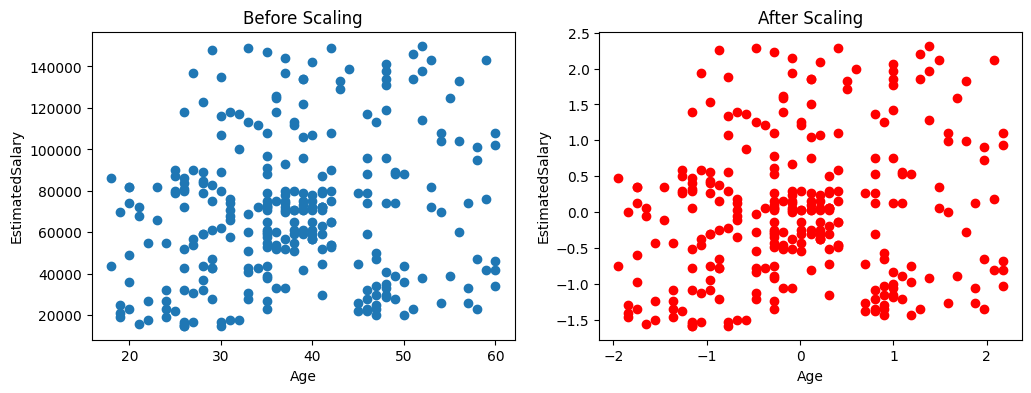

In [ ]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 4))

ax1.scatter(X_train_processed['Age'], X_train_processed['EstimatedSalary'])
ax1.set_xlabel('Age')
ax1.set_ylabel('EstimatedSalary')
ax1.set_title('Before Scaling')

ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color = 'red')
ax2.set_xlabel('Age')
ax2.set_ylabel('EstimatedSalary')
ax2.set_title('After Scaling')

plt.show()

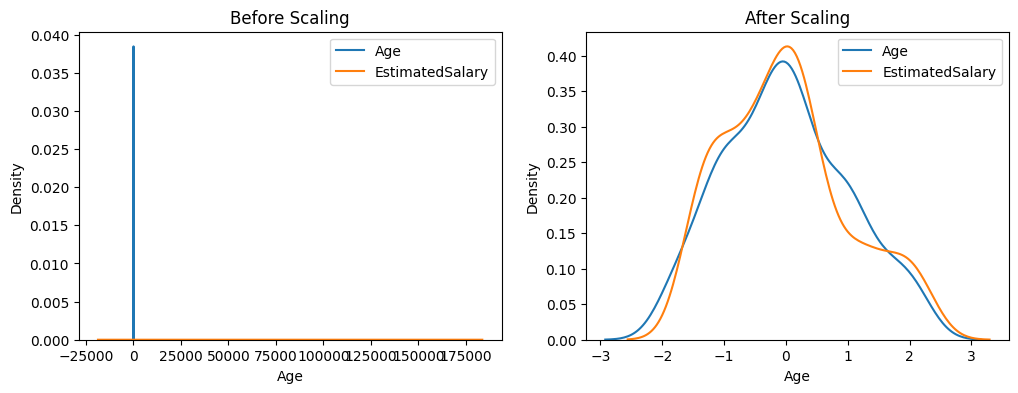

In [ ]:
import seaborn as sns
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 4))

ax1.set_title('Before Scaling')
sns.kdeplot(X_train_processed['Age'], ax=ax1, label='Age')
sns.kdeplot(X_train_processed['EstimatedSalary'], ax=ax1, label='EstimatedSalary')
ax1.legend()

ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2, label='Age')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2, label='EstimatedSalary')
ax2.legend()
plt.show()

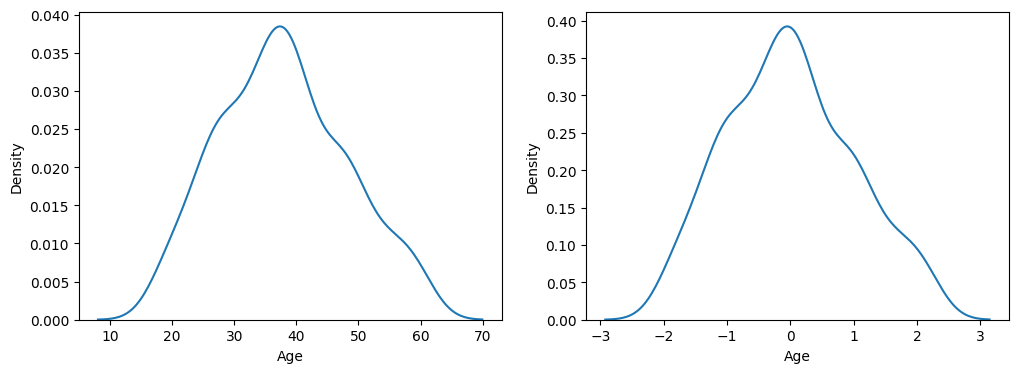

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,4))

sns.kdeplot(X_train_processed['Age'],ax = ax1)

sns.kdeplot(X_train_scaled['Age'], ax = ax2)

plt.show()



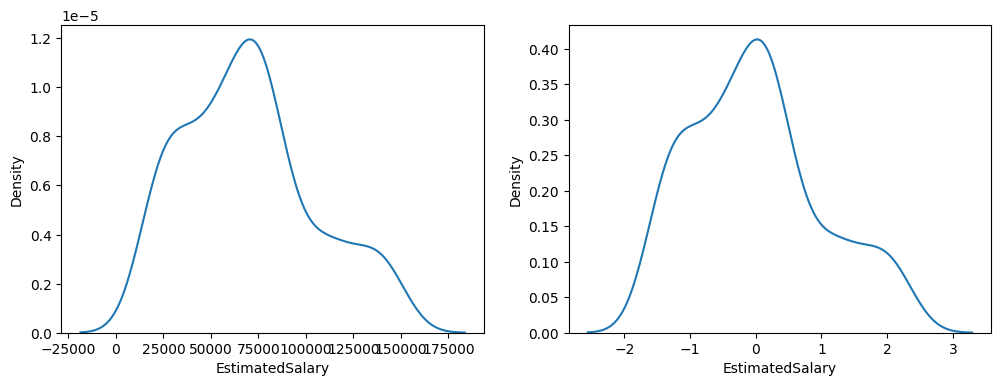

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,4))

sns.kdeplot(X_train_processed['EstimatedSalary'],ax = ax1)

sns.kdeplot(X_train_scaled['EstimatedSalary'], ax = ax2)

plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
model_before = LogisticRegression()
model_before.fit(X_train_processed, y_train)

LogisticRegression()

In [ ]:
y_pred_scaled = model.predict(X_test_scaled)
y_pred_before = model_before.predict(X_test_processed)

In [ ]:
from sklearn.metrics import accuracy_score
print('Scaled',accuracy_score(y_test, y_pred_scaled))
print('Actual',accuracy_score(y_test, y_pred_before))
#mathematical improvements have been added to python over the time to optimize the gradient descent algorithm.


Scaled 0.8666666666666667
Actual 0.875


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train_scaled, y_train)

model_before = DecisionTreeClassifier()
model_before.fit(X_train_processed, y_train)

y_pred_scaled = model.predict(X_test_scaled)
y_pred_before = model_before.predict(X_test_processed)

print('Scaled',accuracy_score(y_test, y_pred_scaled))
print('Actual',accuracy_score(y_test, y_pred_before))

Scaled 0.875
Actual 0.875


Effect of Outliers

In [ ]:
age_outliers = [5, 10, 95]
salary_outliers = [1000000, 2200, 20000]

outlier_data = pd.DataFrame({
    'Age': age_outliers,
    'EstimatedSalary': salary_outliers
})

# Append outliers to X_train_processed
X_train_processed_outliers = pd.concat([X_train_processed, outlier_data], ignore_index=True)

# Scale the outlier data using the existing scaler
outlier_data_scaled = scaler.transform(outlier_data)
outlier_data_scaled_df = pd.DataFrame(outlier_data_scaled, columns=X_train_scaled.columns)

# Append scaled outliers to X_train_scaled
X_train_scaled_outliers = pd.concat([X_train_scaled, outlier_data_scaled_df], ignore_index=True)

print("X_train_processed with outliers (last 3 rows):\n", X_train_processed_outliers.tail(3))
print("\nX_train_scaled with outliers (last 3 rows):\n", X_train_scaled_outliers.tail(3))

X_train_processed with outliers (last 3 rows):
      Age  EstimatedSalary
280    5          1000000
281   10             2200
282   95            20000

X_train_scaled with outliers (last 3 rows):
           Age  EstimatedSalary
280 -3.222009        26.900290
281 -2.731809        -1.955134
282  5.601575        -1.440375


In [ ]:
# Create corresponding y_train for outliers (assuming 'Purchased' = 0 for the outliers)
y_outlier_values = pd.Series([0] * len(age_outliers))
y_train_outliers = pd.concat([y_train, y_outlier_values], ignore_index=True)


print("--- Logistic Regression with Outliers ---")
# Logistic Regression (Processed Data with Outliers)
model_lr_processed_outliers = LogisticRegression(C=1.0) # Using default C=1.0 for processed
model_lr_processed_outliers.fit(X_train_processed_outliers, y_train_outliers)
y_pred_lr_processed_outliers = model_lr_processed_outliers.predict(X_test_processed)
print('LR (Processed + Outliers):', accuracy_score(y_test, y_pred_lr_processed_outliers))

# Logistic Regression (Scaled Data with Outliers)
model_lr_scaled_outliers = LogisticRegression(C=10.0) # Using C=10.0 as previously discussed for scaled
model_lr_scaled_outliers.fit(X_train_scaled_outliers, y_train_outliers)
y_pred_lr_scaled_outliers = model_lr_scaled_outliers.predict(X_test_scaled)
print('LR (Scaled + Outliers):', accuracy_score(y_test, y_pred_lr_scaled_outliers))

print("\n--- Decision Tree with Outliers ---")
# Decision Tree (Processed Data with Outliers)
model_dt_processed_outliers = DecisionTreeClassifier()
model_dt_processed_outliers.fit(X_train_processed_outliers, y_train_outliers)
y_pred_dt_processed_outliers = model_dt_processed_outliers.predict(X_test_processed)
print('DT (Processed + Outliers):', accuracy_score(y_test, y_pred_dt_processed_outliers))

# Decision Tree (Scaled Data with Outliers)
model_dt_scaled_outliers = DecisionTreeClassifier()
model_dt_scaled_outliers.fit(X_train_scaled_outliers, y_train_outliers)
y_pred_dt_scaled_outliers = model_dt_scaled_outliers.predict(X_test_scaled)
print('DT (Scaled + Outliers):', accuracy_score(y_test, y_pred_dt_scaled_outliers))

--- Logistic Regression with Outliers ---
LR (Processed + Outliers): 0.8666666666666667
LR (Scaled + Outliers): 0.8666666666666667

--- Decision Tree with Outliers ---
DT (Processed + Outliers): 0.875
DT (Scaled + Outliers): 0.875


Feature Scaling - Normalization

Normalization is a technique often applied as a part of data preparation for machine learning. The goal of normalization is to change the values of numerical columns in the dataset to use a common scale, without distorting differences in the ranges of values or losing information

In [ ]:
df = pd.read_csv('wine_data.csv', header=None, usecols=[0,1,2])
df.columns = ['Class label', 'Alcohol', 'Malic acid']
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

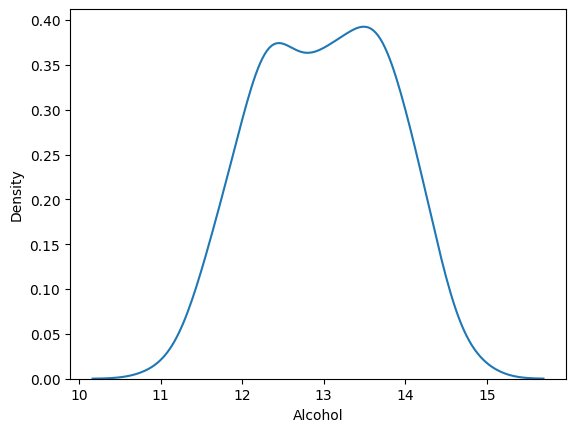

In [ ]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

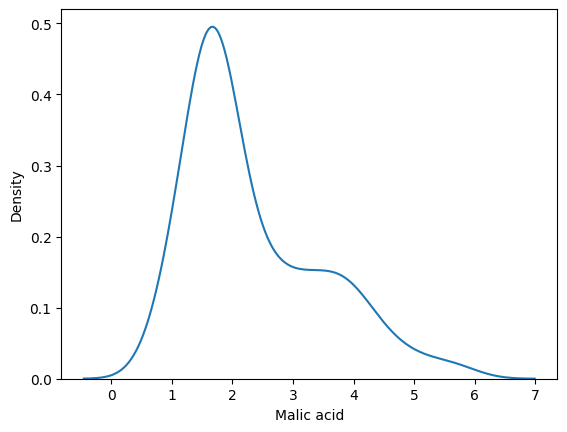

In [ ]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

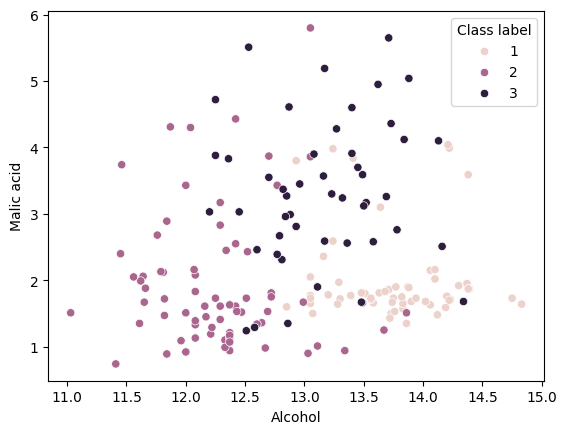

In [ ]:
sns.scatterplot(x = df['Alcohol'],y= df['Malic acid'], hue = df['Class label'])

In [ ]:
from sklearn.model_selection import train_test_split
X_train , X_test, y_train , y_test = train_test_split(df.drop('Class label', axis =1),
                                                      df['Class label'],
                                                      test_size = 0.3,
                                                      random_state = 0)

In [ ]:
X_train.shape, X_test.shape

((124, 2), (54, 2))

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [ ]:
np.round(X_train.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [ ]:
np.round(X_train_scaled.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


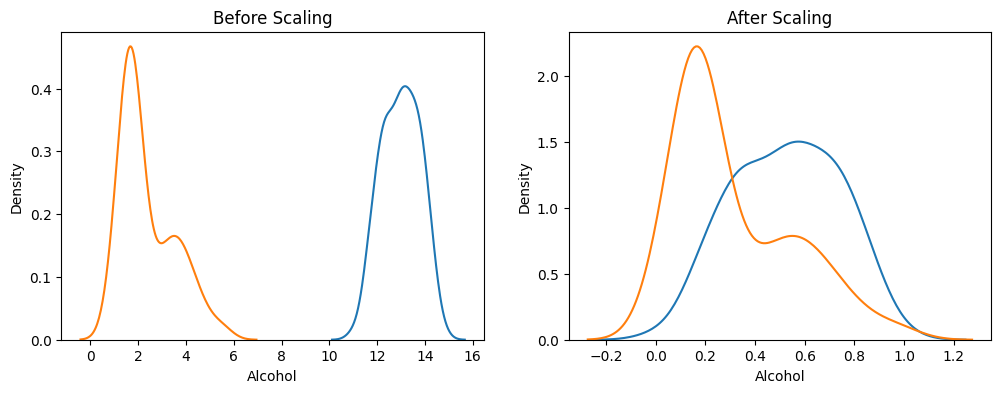

In [ ]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,4))

sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax=ax1)
ax1.set_title('Before Scaling')

sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
ax2.set_title('After Scaling')

plt.show()

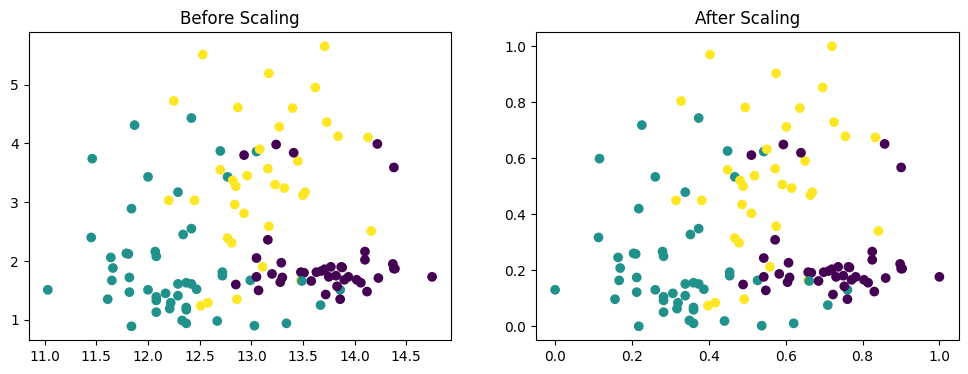

In [ ]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,4))

ax1.scatter(X_train['Alcohol'],X_train['Malic acid'], c = y_train)
ax1.set_title('Before Scaling')

ax2.scatter(X_train_scaled['Alcohol'],X_train_scaled['Malic acid'], c = y_train)
ax2.set_title('After Scaling')

plt.show()

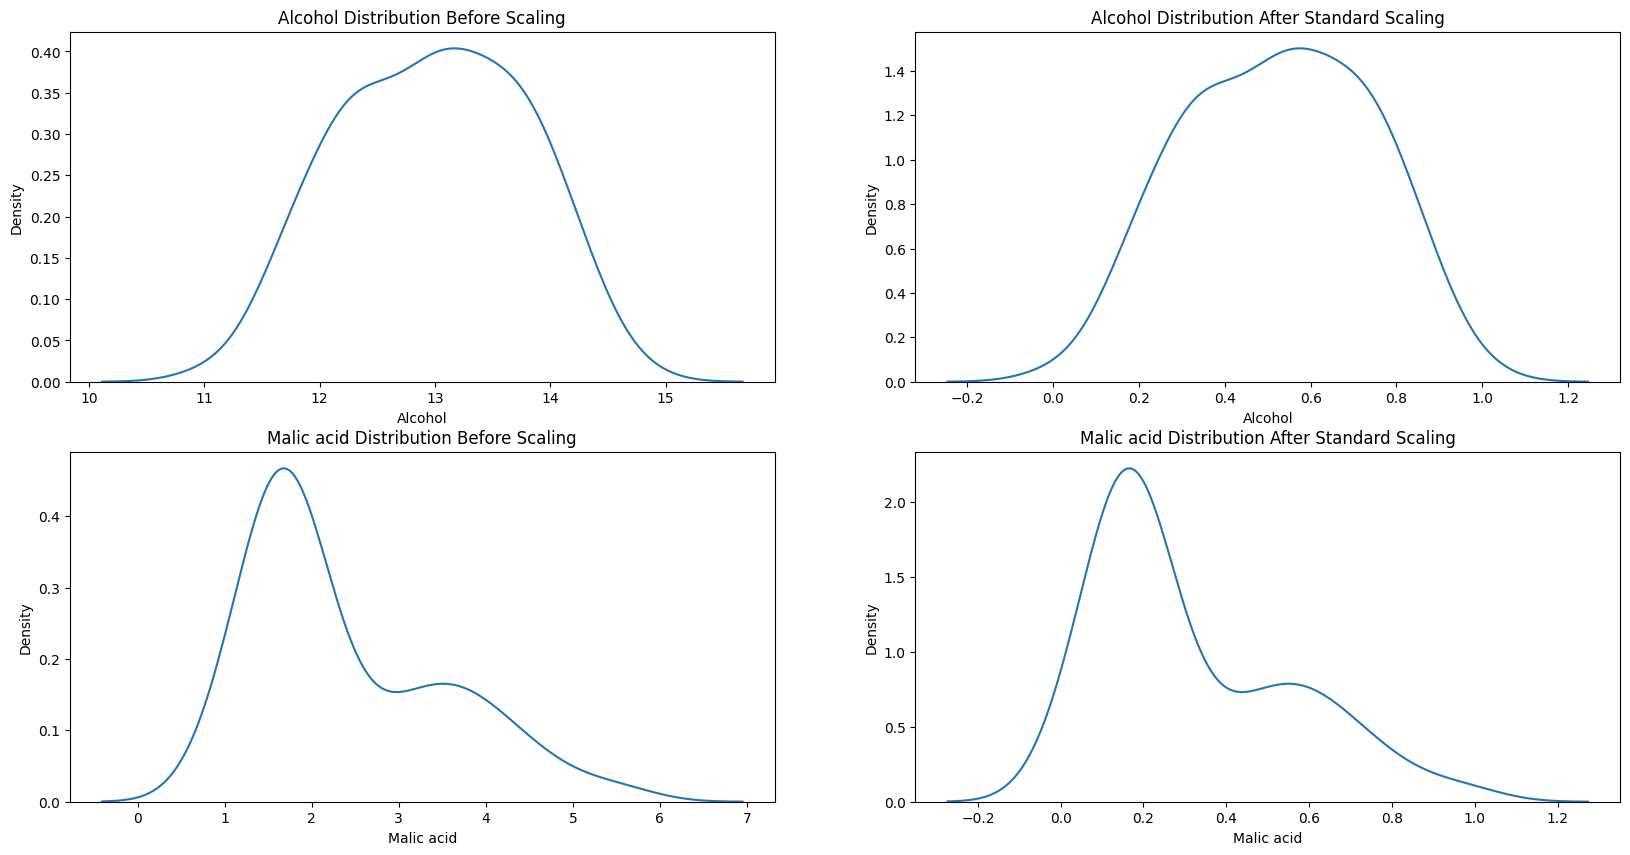

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(ncols=2,nrows =2, figsize=(20, 10))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)

#before scaling
ax3.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax3)

# after scaling
ax4.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax4)
plt.show()


--- MaxAbs Scaling ---
X_train_maxabs_scaled describe:
        Alcohol  Malic acid
count    124.0       124.0
mean       0.9         0.4
std        0.1         0.2
min        0.7         0.2
25%        0.8         0.3
50%        0.9         0.3
75%        0.9         0.6
max        1.0         1.0


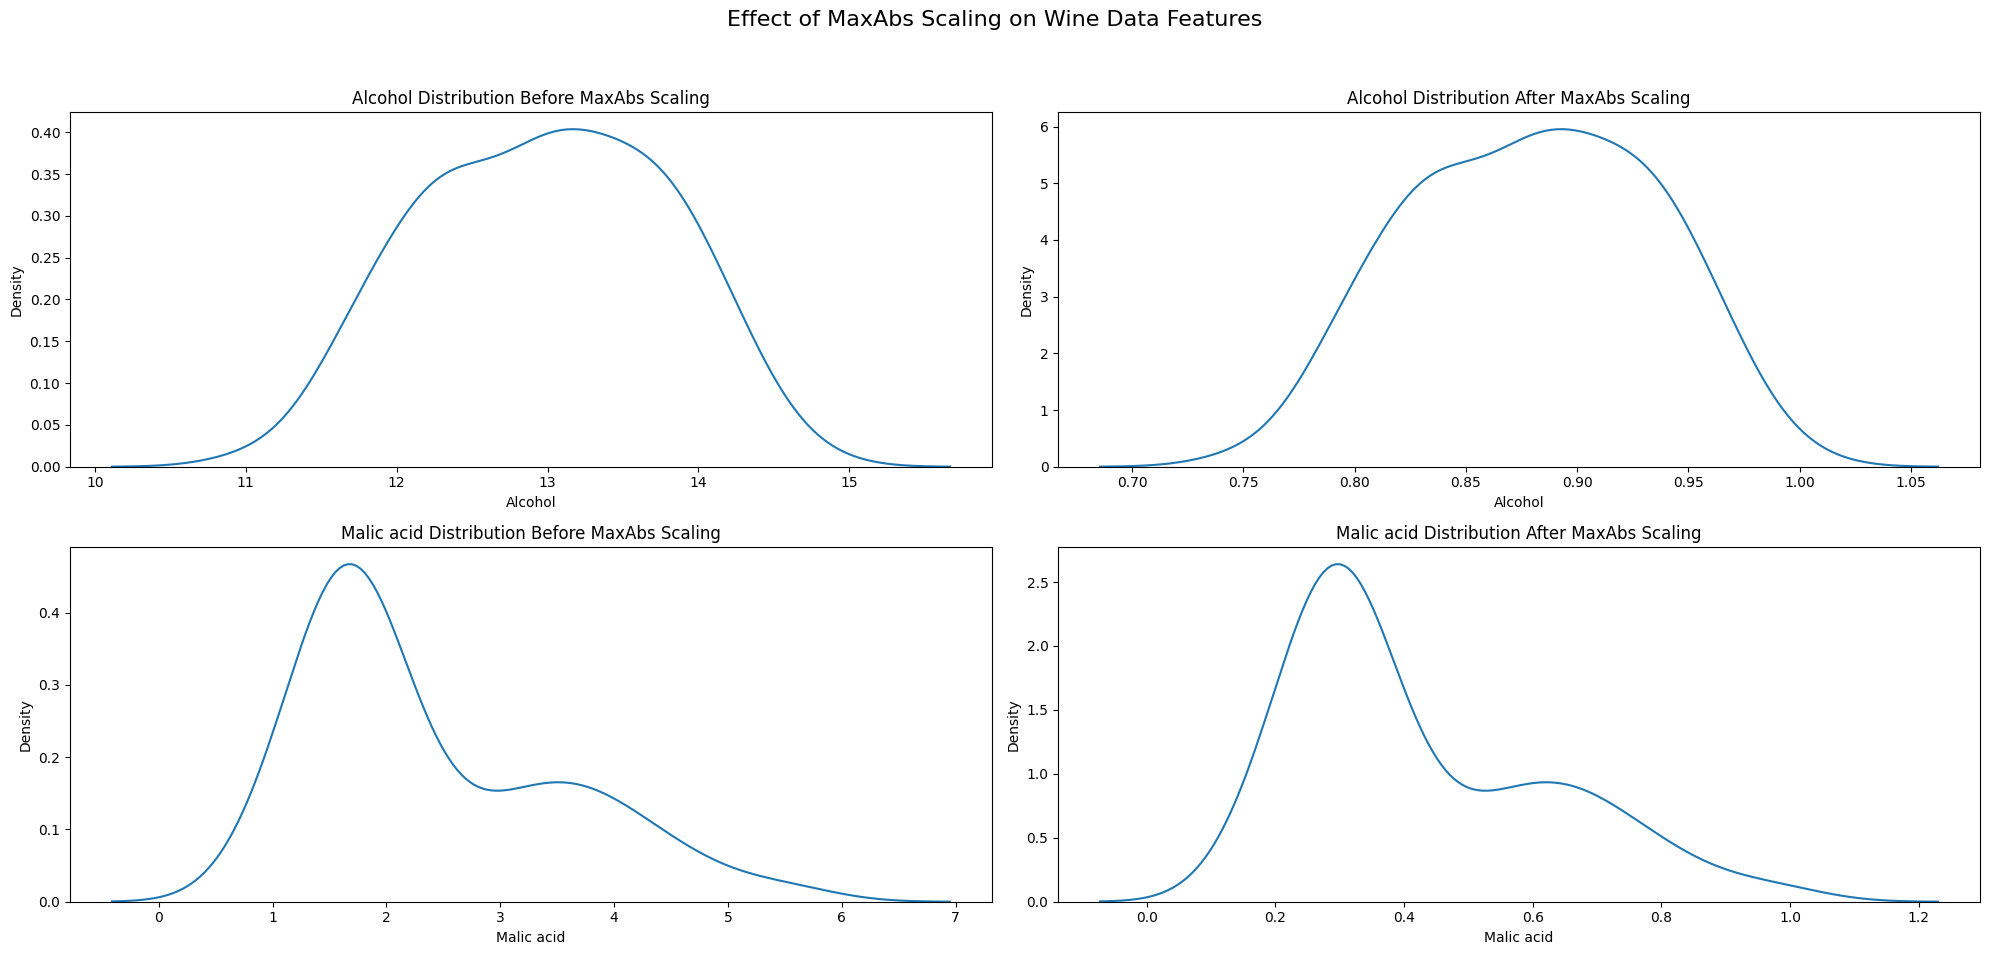


--- Robust Scaling ---
X_train_robust_scaled describe:
        Alcohol  Malic acid
count    124.0       124.0
mean      -0.0         0.3
std        0.6         0.7
min       -1.6        -0.6
25%       -0.5        -0.2
50%        0.0         0.0
75%        0.5         0.8
max        1.3         2.3


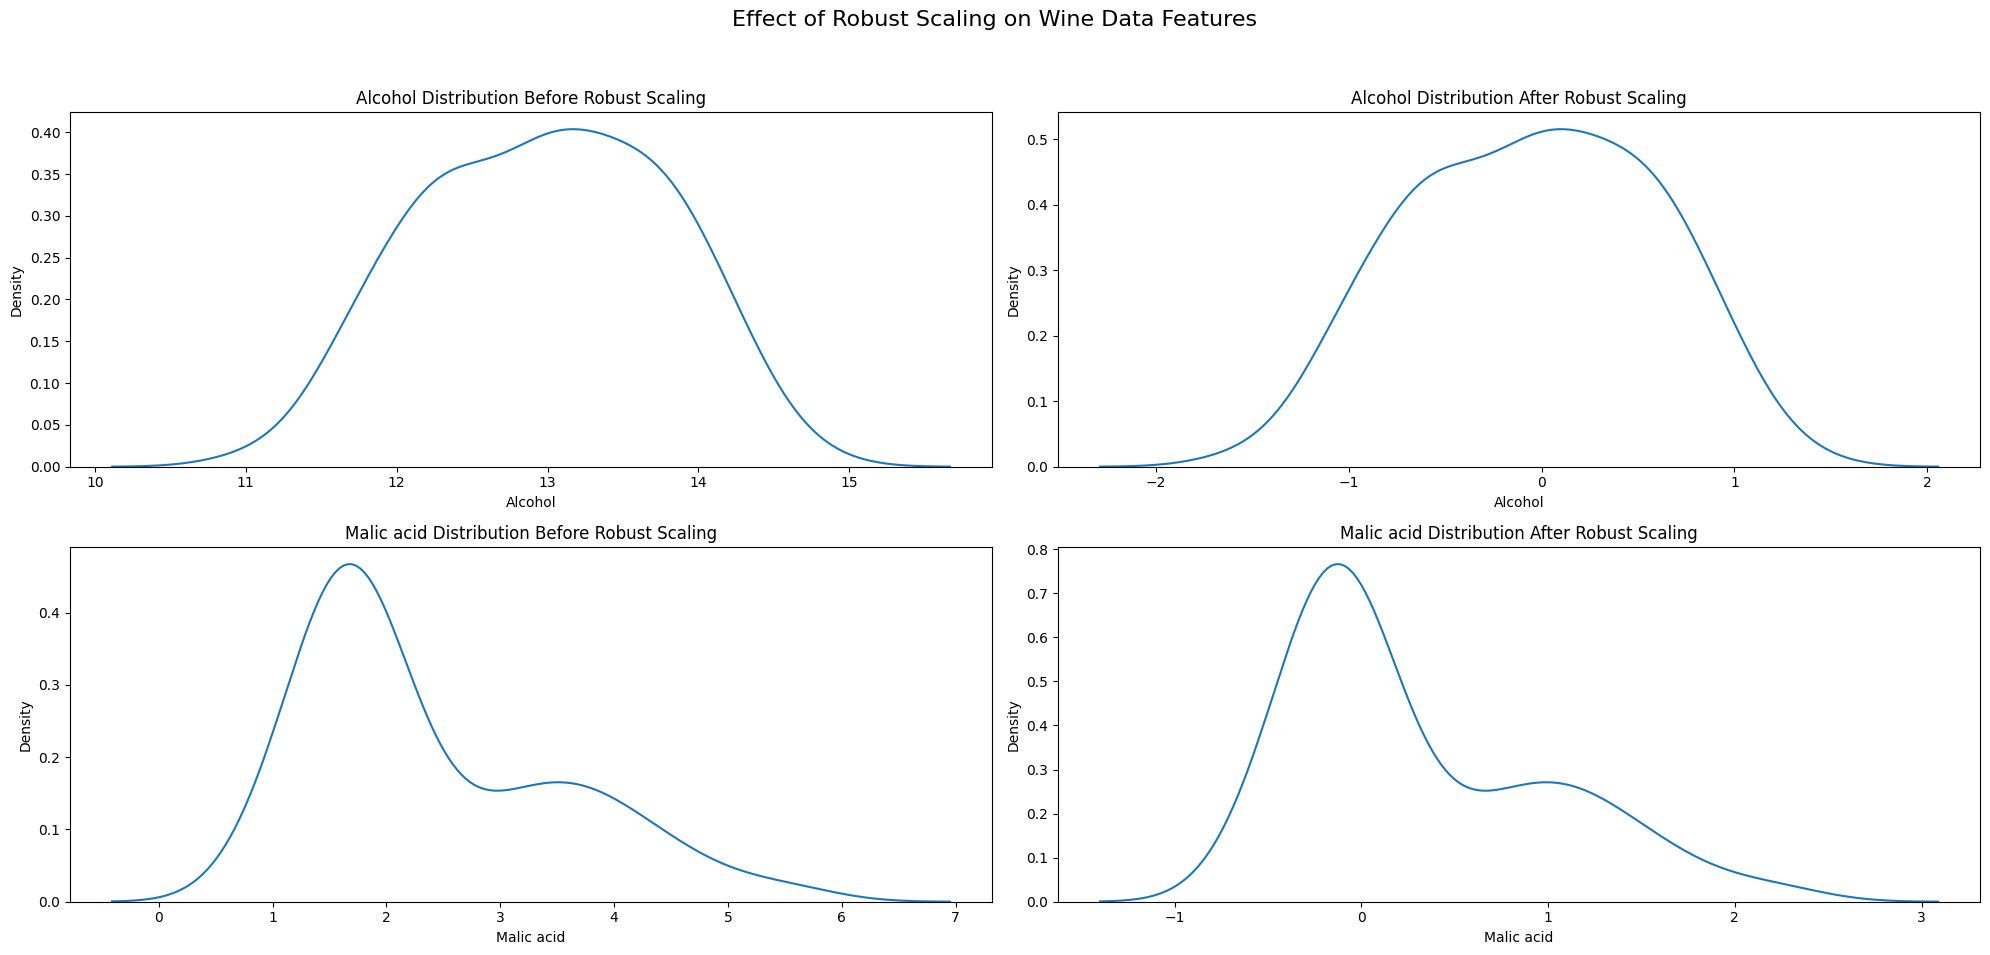

In [ ]:
from sklearn.preprocessing import MaxAbsScaler, RobustScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- MaxAbsScaler ---
print("\n--- MaxAbs Scaling ---")
maxabs_scaler = MaxAbsScaler()

maxabs_scaler.fit(X_train)

X_train_maxabs_scaled = maxabs_scaler.transform(X_train)
X_test_maxabs_scaled = maxabs_scaler.transform(X_test)

X_train_maxabs_scaled = pd.DataFrame(X_train_maxabs_scaled, columns=X_train.columns)
X_test_maxabs_scaled = pd.DataFrame(X_test_maxabs_scaled, columns=X_test.columns)

print("X_train_maxabs_scaled describe:\n", np.round(X_train_maxabs_scaled.describe(), 1))

# Visualization for MaxAbsScaler
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(ncols=2, nrows=2, figsize=(20, 10))

# Alcohol distribution
ax1.set_title('Alcohol Distribution Before MaxAbs Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

ax2.set_title('Alcohol Distribution After MaxAbs Scaling')
sns.kdeplot(X_train_maxabs_scaled['Alcohol'], ax=ax2)

# Malic acid distribution
ax3.set_title('Malic acid Distribution Before MaxAbs Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax3)

ax4.set_title('Malic acid Distribution After MaxAbs Scaling')
sns.kdeplot(X_train_maxabs_scaled['Malic acid'], ax=ax4)
plt.suptitle('Effect of MaxAbs Scaling on Wine Data Features', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



# --- RobustScaler ---
print("\n--- Robust Scaling ---")
robust_scaler = RobustScaler()

robust_scaler.fit(X_train)

X_train_robust_scaled = robust_scaler.transform(X_train)
X_test_robust_scaled = robust_scaler.transform(X_test)

X_train_robust_scaled = pd.DataFrame(X_train_robust_scaled, columns=X_train.columns)
X_test_robust_scaled = pd.DataFrame(X_test_robust_scaled, columns=X_test.columns)

print("X_train_robust_scaled describe:\n", np.round(X_train_robust_scaled.describe(), 1))

# Visualization for RobustScaler
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(ncols=2, nrows=2, figsize=(20, 10))

# Alcohol distribution
ax1.set_title('Alcohol Distribution Before Robust Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

ax2.set_title('Alcohol Distribution After Robust Scaling')
sns.kdeplot(X_train_robust_scaled['Alcohol'], ax=ax2)

# Malic acid distribution
ax3.set_title('Malic acid Distribution Before Robust Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax3)

ax4.set_title('Malic acid Distribution After Robust Scaling')
sns.kdeplot(X_train_robust_scaled['Malic acid'], ax=ax4)
plt.suptitle('Effect of Robust Scaling on Wine Data Features', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("\n--- Logistic Regression Accuracy Comparison ---")

# 1. Logistic Regression with Unscaled Data
model_lr_unscaled = LogisticRegression(random_state=0, solver='liblinear') # Added solver for older versions
model_lr_unscaled.fit(X_train, y_train)
y_pred_unscaled = model_lr_unscaled.predict(X_test)
print(f"Accuracy (Unscaled): {accuracy_score(y_test, y_pred_unscaled):.4f}")

# 2. Logistic Regression with MinMaxScaler (X_train_scaled, X_test_scaled)
model_lr_minmax = LogisticRegression(random_state=0, solver='liblinear')
model_lr_minmax.fit(X_train_scaled, y_train)
y_pred_minmax = model_lr_minmax.predict(X_test_scaled)
print(f"Accuracy (MinMax Scaled): {accuracy_score(y_test, y_pred_minmax):.4f}")

# 3. Logistic Regression with MaxAbsScaler (X_train_maxabs_scaled, X_test_maxabs_scaled)
model_lr_maxabs = LogisticRegression(random_state=0, solver='liblinear')
model_lr_maxabs.fit(X_train_maxabs_scaled, y_train)
y_pred_maxabs = model_lr_maxabs.predict(X_test_maxabs_scaled)
print(f"Accuracy (MaxAbs Scaled): {accuracy_score(y_test, y_pred_maxabs):.4f}")

# 4. Logistic Regression with RobustScaler (X_train_robust_scaled, X_test_robust_scaled)
model_lr_robust = LogisticRegression(random_state=0, solver='liblinear')
model_lr_robust.fit(X_train_robust_scaled, y_train)
y_pred_robust = model_lr_robust.predict(X_test_robust_scaled)
print(f"Accuracy (Robust Scaled): {accuracy_score(y_test, y_pred_robust):.4f}")


--- Logistic Regression Accuracy Comparison ---
Accuracy (Unscaled): 0.7037
Accuracy (MinMax Scaled): 0.7778
Accuracy (MaxAbs Scaled): 0.5185
Accuracy (Robust Scaled): 0.7778


Ordinal Encoding

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('customer.csv')

In [ ]:
df.sample()

,age,gender,review,education,purchased
36,34,Female,Good,UG,Yes


In [ ]:
df = df.iloc[:,2:]
df

,review,education,purchased
0,Average,School,No
1,Poor,UG,No
2,Good,PG,No
3,Good,PG,No
4,Average,UG,No
5,Average,School,Yes
6,Good,School,No
7,Poor,School,Yes
8,Average,UG,No
9,Good,UG,Yes


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,0:2], df.iloc[:,-1], test_size=0.3, random_state=0)


In [ ]:
oe = OrdinalEncoder(categories=[['Poor','Average','Good'],['School','UG','PG']])
oe.fit(X_train)


OrdinalEncoder(categories=[['Poor', 'Average', 'Good'], ['School', 'UG', 'PG']])

In [ ]:
X_train = oe.transform(X_train)
X_test = oe.transform(X_test)

In [ ]:
oe.categories_

[array(['Poor', 'Average', 'Good'], dtype=object),
 array(['School', 'UG', 'PG'], dtype=object)]

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(y_train)

LabelEncoder()

In [ ]:
le.classes_

array(['No', 'Yes'], dtype=object)

In [ ]:
y_train = le.transform(y_train)
y_test = le.transform(y_test)

In [ ]:
y_train, y_test

(array([1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
        1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0]),
 array([0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0]))

One Hot Encoding

Multicollinearity - Mathematical relation between input columns

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('cars.csv')

1. One hot encoding

In [ ]:
pd.get_dummies(df, columns=['fuel','owner'],dtype = int)

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,0,1,0,0,1,0,0,0,0
1,Skoda,120000,370000,0,1,0,0,0,0,1,0,0
2,Honda,140000,158000,0,0,0,1,0,0,0,0,1
3,Hyundai,127000,225000,0,1,0,0,1,0,0,0,0
4,Maruti,120000,130000,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,0,0,0,1,1,0,0,0,0
8124,Hyundai,119000,135000,0,1,0,0,0,1,0,0,0
8125,Maruti,120000,382000,0,1,0,0,1,0,0,0,0
8126,Tata,25000,290000,0,1,0,0,1,0,0,0,0


2. K-1 OneHotEncoding

In [ ]:
pd.get_dummies(df, columns=['fuel','owner'], drop_first=True, dtype = int)

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,1,0,0,0,0,0,0
1,Skoda,120000,370000,1,0,0,0,1,0,0
2,Honda,140000,158000,0,0,1,0,0,0,1
3,Hyundai,127000,225000,1,0,0,0,0,0,0
4,Maruti,120000,130000,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,0,0,1,0,0,0,0
8124,Hyundai,119000,135000,1,0,0,1,0,0,0
8125,Maruti,120000,382000,1,0,0,0,0,0,0
8126,Tata,25000,290000,1,0,0,0,0,0,0


3. OHE using Sklearn

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,0:4], df.iloc[:,-1], test_size=0.3, random_state=0)


In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop = 'first', sparse_output = False,dtype = 'int32')
X_train_new = ohe.fit_transform(X_train[['fuel','owner']])
X_test_new = ohe.transform(X_test[['fuel','owner']])

In [ ]:

X_train_new, X_test_new

(array([[0, 0, 1, ..., 0, 0, 0],
        [0, 0, 1, ..., 0, 0, 0],
        [0, 0, 1, ..., 0, 0, 0],
        ...,
        [0, 0, 1, ..., 1, 0, 0],
        [1, 0, 0, ..., 0, 0, 0],
        [0, 0, 1, ..., 0, 0, 0]], dtype=int32),
 array([[1, 0, 0, ..., 0, 0, 0],
        [1, 0, 0, ..., 0, 0, 0],
        [0, 0, 1, ..., 0, 0, 0],
        ...,
        [1, 0, 0, ..., 0, 0, 0],
        [1, 0, 0, ..., 1, 0, 0],
        [1, 0, 0, ..., 0, 0, 0]], dtype=int32))

In [ ]:
np.hstack((X_train[['brand','km_driven']].values, X_train_new)).shape

(5689, 9)

4. OHE with Top Categories

In [ ]:
df['brand'].value_counts()

,count
brand,
Maruti,2448
Hyundai,1415
Mahindra,772
Tata,734
Toyota,488
Honda,467
Ford,397
Chevrolet,230
Renault,228


In [ ]:
counts = df['brand'].value_counts()

In [ ]:
df['brand'].nunique()
threshold = 100

In [ ]:
repl = counts[counts <= threshold].index

In [ ]:
repl

Index(['Nissan', 'Jaguar', 'Volvo', 'Datsun', 'Mercedes-Benz', 'Fiat', 'Audi',
       'Lexus', 'Jeep', 'Mitsubishi', 'Land', 'Force', 'Isuzu', 'Ambassador',
       'Kia', 'MG', 'Daewoo', 'Ashok', 'Opel', 'Peugeot'],
      dtype='object', name='brand')

In [ ]:
pd.get_dummies(df['brand'].replace(repl, 'uncommon'), dtype=int)

,BMW,Chevrolet,Ford,Honda,Hyundai,Mahindra,Maruti,Renault,Skoda,Tata,Toyota,Volkswagen,uncommon
0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,0,0,0,0,1,0,0,0,0,0,0,0,0
8124,0,0,0,0,1,0,0,0,0,0,0,0,0
8125,0,0,0,0,0,0,1,0,0,0,0,0,0
8126,0,0,0,0,0,0,0,0,0,1,0,0,0


Column Transformer

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
df = pd.read_csv('covid_toy.csv')

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['has_covid']), df['has_covid'],
                                                    test_size=0.2)

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
fever,10
cough,0
city,0
has_covid,0


1. Without Column Transformer

In [ ]:
si = SimpleImputer()
X_train_fever = si.fit_transform(X_train[['fever']])

# also the test data
X_test_fever = si.fit_transform(X_test[['fever']])

X_train_fever.shape

(80, 1)

In [ ]:
oe = OrdinalEncoder(categories=[['Mild','Strong']])
X_train_cough = oe.fit_transform(X_train[['cough']])

# also the test data
X_test_cough = oe.fit_transform(X_test[['cough']])

X_train_cough.shape

(80, 1)

In [ ]:
ohe = OneHotEncoder(drop = 'first', sparse_output=False)
X_train_gender_city = ohe.fit_transform(X_train[['gender','city']])

X_test_gender_city = ohe.fit_transform(X_test[['gender','city']])

X_train_gender_city.shape

(80, 4)

In [ ]:
X_train_age = X_train.drop(columns=['gender','fever','cough','city']).values

# also the test data
X_test_age = X_test.drop(columns=['gender','fever','cough','city']).values

X_train_age.shape

(80, 1)

In [ ]:
X_train_transformed = np.concatenate((X_train_age,X_train_fever,X_train_gender_city,X_train_cough),axis=1)

X_test_transformed = np.concatenate((X_test_age,X_test_fever,X_test_gender_city,X_test_cough),axis=1)

X_train_transformed.shape

(80, 7)

2. With Column Transformer

In [ ]:
from sklearn.compose import ColumnTransformer

In [ ]:
transformer = ColumnTransformer(transformers =[
    ('tnf1', SimpleImputer(), ['fever']),
    ('tnf2', OrdinalEncoder(categories=[['Mild','Strong']], dtype=int), ['cough']),
    ('tnf3', OneHotEncoder(drop = 'first', sparse_output=False, dtype = int), ['gender','city'])
], remainder = 'passthrough')

In [ ]:
X_train_new = transformer.fit_transform(X_train).astype(int)

In [ ]:
X_test_new = transformer.transform(X_test)

Machine Learning Pipelines

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df = pd.read_csv('titanic.csv')

In [ ]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

In [ ]:
# Step 1 -> train/test/split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['Survived']),
                                                 df['Survived'],
                                                 test_size=0.2,
                                                random_state=42)

In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [ ]:
# Applying imputation

si_age = SimpleImputer()
si_embarked = SimpleImputer(strategy='most_frequent')

X_train_age = si_age.fit_transform(X_train[['Age']])
X_train_embarked = si_embarked.fit_transform(X_train[['Embarked']])

X_test_age = si_age.transform(X_test[['Age']])
X_test_embarked = si_embarked.transform(X_test[['Embarked']])

In [ ]:
# one hot encoding Sex and Embarked

ohe_sex = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
ohe_embarked = OneHotEncoder(sparse_output=False,handle_unknown='ignore')

X_train_sex = ohe_sex.fit_transform(X_train[['Sex']])
X_train_embarked = ohe_embarked.fit_transform(X_train_embarked)

X_test_sex = ohe_sex.transform(X_test[['Sex']])
X_test_embarked = ohe_embarked.transform(X_test_embarked)

In [ ]:
X_train_rem = X_train.drop(columns=['Sex','Age','Embarked'])
X_test_rem = X_test.drop(columns=['Sex','Age','Embarked'])

In [ ]:
X_train_transformed = np.concatenate((X_train_rem,X_train_age,X_train_sex,X_train_embarked),axis=1)
X_test_transformed = np.concatenate((X_test_rem,X_test_age,X_test_sex,X_test_embarked),axis=1)

In [ ]:
X_train_transformed.shape, X_test_transformed.shape

((712, 10), (179, 10))

In [ ]:
clf = DecisionTreeClassifier()
clf.fit(X_train_transformed,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = clf.predict(X_test_transformed)
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7821229050279329

In [ ]:
import pickle
pickle.dump(ohe_sex,open('models/ohe_sex.pkl','wb'))
pickle.dump(ohe_embarked,open('models/ohe_embarked.pkl','wb'))
pickle.dump(clf,open('models/clf.pkl','wb'))
pickle.dump(si_age,open('models/si_age.pkl','wb'))
pickle.dump(si_embarked,open('models/si_embarked.pkl','wb'))


Prediction without Pipeline

In [ ]:
ohe_sex = pickle.load(open('models/ohe_sex.pkl','rb'))
ohe_embarked = pickle.load(open('models/ohe_embarked.pkl','rb'))
clf = pickle.load(open('models/clf.pkl','rb'))

In [ ]:
test_input = np.array([2, 'male', 31.0 , 0 , 0 , 10.5, 'S'],dtype = object).reshape(1,7)

In [ ]:
test_input_sex = ohe_sex.transform(test_input[:,1].reshape(1,1))
test_input_embarked = ohe_embarked.transform(test_input[:,-1].reshape(1,1))
test_input_age = test_input[:,2].reshape(1,1)
test_input_transformed = np.concatenate((test_input[:,[0,3,4,5]],test_input_age,test_input_sex,test_input_embarked),axis=1)
test_input_transformed.shape

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


(1, 10)

In [ ]:
test_input_transformed

array([[2, 0, 0, 10.5, 31.0, 0.0, 1.0, 0.0, 0.0, 1.0]], dtype=object)

In [ ]:
clf.predict(test_input_transformed)

array([0])

Using Pipelines

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.tree import DecisionTreeClassifier

In [ ]:
df = pd.read_csv('titanic.csv')

In [ ]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['Survived']),
                                                 df['Survived'],
                                                 test_size=0.2,
                                                random_state=42)


In [ ]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.5000,S
733,2,male,23.0,0,0,13.0000,S
382,3,male,32.0,0,0,7.9250,S
704,3,male,26.0,1,0,7.8542,S
813,3,female,6.0,4,2,31.2750,S


In [ ]:
# imputation transformer
trf1 = ColumnTransformer([
    ('impute_age',SimpleImputer(),[2]),
    ('impute_embarked',SimpleImputer(strategy='most_frequent'),[6])
],remainder='passthrough')


# one hot encoding
trf2 = ColumnTransformer([
    ('ohe_sex_embarked',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),[1,6])
],remainder='passthrough')

# Scaling
trf3 = ColumnTransformer([
    ('scale',MinMaxScaler(),slice(0,10))
])

# Feature selection
trf4 = SelectKBest(score_func=chi2,k=8)

# train the model
trf5 = DecisionTreeClassifier()

Create Pipeline

In [ ]:
pipe = Pipeline([
    ('trf1',trf1),
    ('trf2',trf2),
    ('trf3',trf3),
    ('trf4',trf4),
    ('trf5',trf5)
])

In [ ]:

# train
pipe.fit(X_train,y_train)

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('impute_age', SimpleImputer(),
                                                  [2]),
                                                 ('impute_embarked',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [6])])),
                ('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe_sex_embarked',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 6])])),
                ('trf3',
                 ColumnTransformer(transformers=[('scale', MinMaxScaler(),
                                                  slice(0, 10, None))])),
                ('trf4',
                 SelectKBest(k=8,
                             score_func=<function chi2 at 0x77fbd1a55080>)),
                ('trf5', DecisionTreeClassifier())])

Exploring the Pipeline

In [ ]:
# Code here
pipe.named_steps['trf1'].transformers_[1][1].statistics_


array(['S'], dtype=object)

In [ ]:

# Display Pipeline

from sklearn import set_config
set_config(display='diagram')

In [ ]:
# Display Pipeline
from sklearn import set_config
set_config(display='diagram')

In [ ]:
# Predict
y_pred = pipe.predict(X_test)
y_pred

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6256983240223464

Cross validation using Pipeline

In [ ]:
# gridsearchcv
params = {
    'trf5__max_depth':[1,2,3,4,5,None]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

# Correcting the parameter name to match the explicit step name in the pipeline
params = {
    'trf5__max_depth':[1,2,3,4,5,None]
}

grid = GridSearchCV(pipe, params, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('trf1',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('impute_age',
                                                                         SimpleImputer(),
                                                                         [2]),
                                                                        ('impute_embarked',
                                                                         SimpleImputer(strategy='most_frequent'),
                                                                         [6])])),
                                       ('trf2',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ohe_sex_embarked',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         [1,
                                                                          6])])),
                                       ('trf3',
                                        ColumnTransformer(transformers=[('scale',
                                                                         MinMaxScaler(),
                                                                         slice(0, 10, None))])),
                                       ('trf4',
                                        SelectKBest(k=8,
                                                    score_func=<function chi2 at 0x77fbd1a55080>)),
                                       ('trf5', DecisionTreeClassifier())]),
             param_grid={'trf5__max_depth': [1, 2, 3, 4, 5, None]},
             scoring='accuracy')

In [ ]:
grid.best_score_

np.float64(0.6391214419383433)

In [ ]:
grid.best_params_

{'trf5__max_depth': 2}

In [ ]:
# export
import pickle
pickle.dump(pipe,open('pipe.pkl','wb'))

In [ ]:
pipe = pickle.load(open('pipe.pkl','rb'))

In [ ]:
# Assume user input
test_input2 = np.array([2, 'male', 31.0, 0, 0, 10.5, 'S'],dtype=object).reshape(1,7)

In [ ]:
pipe.predict(test_input2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


array([0])